<a href="https://colab.research.google.com/github/jebunn/Neural-Network/blob/main/Problem_set_02/Problem_set_2ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Dataset path
DATASET_PATH = '/content/drive/MyDrive/bank-data'

# List files in folder
print("📂 Files in dataset folder:")
for f in os.listdir(DATASET_PATH):
    print(f"   {f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Files in dataset folder:
   bank-full.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_curve, roc_auc_score,
                              ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

✅ All libraries imported!


In [ ]:
# Try both common filenames for Bank Marketing dataset
import os

possible_files = ['bank-full.csv', 'bank.csv', 'bank-additional-full.csv',
                  'bank-additional.csv', 'bank_data.csv', 'data.csv']

df = None
for fname in possible_files:
    fpath = os.path.join(DATASET_PATH, fname)
    if os.path.exists(fpath):
        # Try semicolon separator first (standard bank marketing dataset format)
        try:
            df = pd.read_csv(fpath, sep=';')
            if df.shape[1] > 3:
                print(f"✅ Loaded: {fname} with separator ';'")
                break
        except:
            pass
        try:
            df = pd.read_csv(fpath, sep=',')
            if df.shape[1] > 3:
                print(f"✅ Loaded: {fname} with separator ','")
                break
        except:
            pass

if df is None:
    # Manual fallback — update filename if needed
    df = pd.read_csv(os.path.join(DATASET_PATH, os.listdir(DATASET_PATH)[0]), sep=';')
    print(f"✅ Loaded first file found in folder")

print(f"\n📊 Dataset Shape: {df.shape}")
print(f"   Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
print(f"\nColumn Names:\n{list(df.columns)}")

✅ Loaded: bank-full.csv with separator ';'

📊 Dataset Shape: (45211, 17)
   Rows: 45,211 | Columns: 17

Column Names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [ ]:
print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)

print("\n🔹 First 5 rows:")
display(df.head())

print("\n🔹 Data Types & Non-Null Counts:")
display(df.info())

print("\n🔹 Statistical Summary:")
display(df.describe())

print("\n🔹 Missing Values:")
print(df.isnull().sum())

print(f"\n🔹 Target Variable Distribution (y):")
print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

  DATASET OVERVIEW

🔹 First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



🔹 Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


None


🔹 Statistical Summary:


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000



🔹 Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

🔹 Target Variable Distribution (y):
y
no     39922
yes     5289
Name: count, dtype: int64
y
no     88.3%
yes    11.7%
Name: proportion, dtype: object


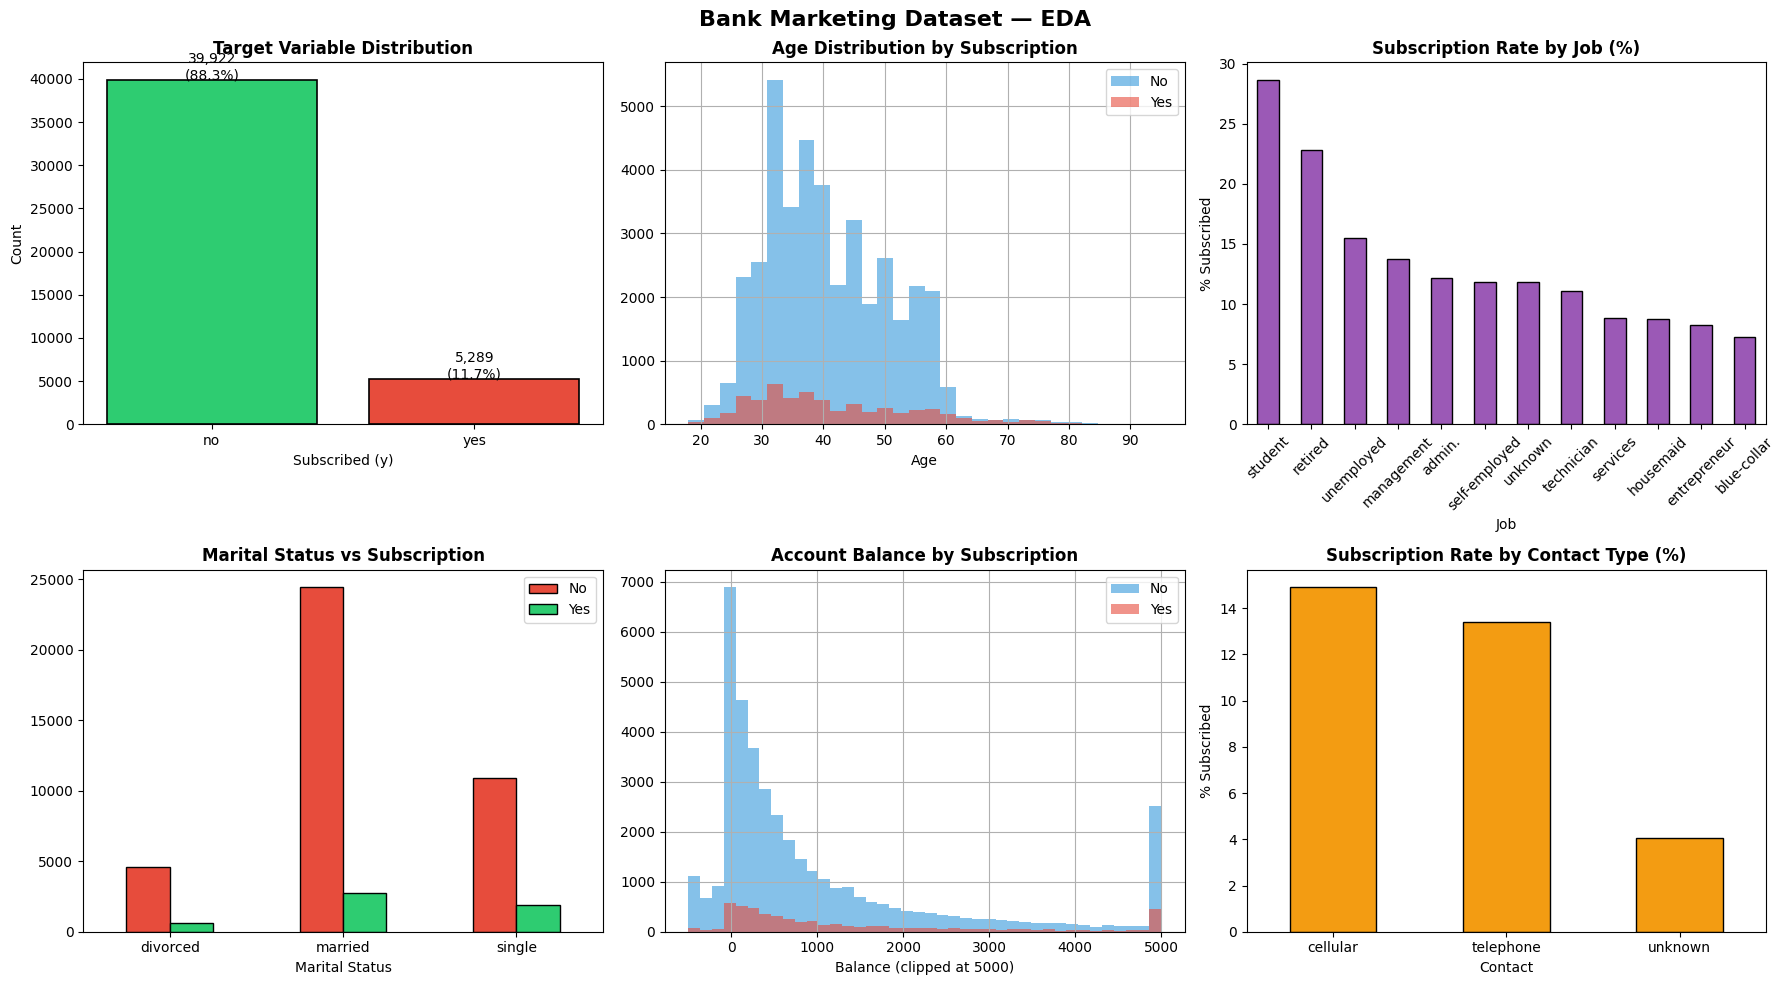

✅ EDA plots saved!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Bank Marketing Dataset — EDA', fontsize=16, fontweight='bold')

# 1. Target distribution
ax = axes[0][0]
counts = df['y'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.2)
ax.set_title('Target Variable Distribution', fontweight='bold')
ax.set_xlabel('Subscribed (y)')
ax.set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)

# 2. Age distribution by target
ax = axes[0][1]
df[df['y']=='no']['age'].hist(ax=ax, alpha=0.6, color='#3498db', label='No', bins=30)
df[df['y']=='yes']['age'].hist(ax=ax, alpha=0.6, color='#e74c3c', label='Yes', bins=30)
ax.set_title('Age Distribution by Subscription', fontweight='bold')
ax.set_xlabel('Age')
ax.legend()

# 3. Job vs Subscription
ax = axes[0][2]
job_sub = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean() * 100).sort_values(ascending=False)
job_sub.plot(kind='bar', ax=ax, color='#9b59b6', edgecolor='black')
ax.set_title('Subscription Rate by Job (%)', fontweight='bold')
ax.set_xlabel('Job')
ax.set_ylabel('% Subscribed')
ax.tick_params(axis='x', rotation=45)

# 4. Marital status
ax = axes[1][0]
mar_counts = df.groupby(['marital', 'y']).size().unstack()
mar_counts.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax.set_title('Marital Status vs Subscription', fontweight='bold')
ax.set_xlabel('Marital Status')
ax.tick_params(axis='x', rotation=0)
ax.legend(['No', 'Yes'])

# 5. Balance distribution
ax = axes[1][1]
df[df['y']=='no']['balance'].clip(-500, 5000).hist(ax=ax, alpha=0.6,
                                                     color='#3498db', label='No', bins=40)
df[df['y']=='yes']['balance'].clip(-500, 5000).hist(ax=ax, alpha=0.6,
                                                      color='#e74c3c', label='Yes', bins=40)
ax.set_title('Account Balance by Subscription', fontweight='bold')
ax.set_xlabel('Balance (clipped at 5000)')
ax.legend()

# 6. Contact type
ax = axes[1][2]
contact_sub = df.groupby('contact')['y'].apply(lambda x: (x=='yes').mean()*100)
contact_sub.plot(kind='bar', ax=ax, color='#f39c12', edgecolor='black')
ax.set_title('Subscription Rate by Contact Type (%)', fontweight='bold')
ax.set_xlabel('Contact')
ax.set_ylabel('% Subscribed')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('/content/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved!")

In [ ]:
df_processed = df.copy()

# Identify column types
categorical_cols = df_processed.select_dtypes(include='object').columns.tolist()
print(f"📌 Categorical columns: {categorical_cols}")

# Separate target
TARGET = 'y'
categorical_cols = [c for c in categorical_cols if c != TARGET]

# Label Encode target
le_target = LabelEncoder()
df_processed[TARGET] = le_target.fit_transform(df_processed[TARGET])
print(f"\n✅ Target encoded: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

# One-Hot Encode categorical features
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)
print(f"\n✅ After one-hot encoding: {df_processed.shape[1]} columns")

# Handle 'unknown' encoded if any column has it
print(f"\n📊 Processed dataset shape: {df_processed.shape}")
display(df_processed.head(3))

📌 Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

✅ Target encoded: {'no': np.int64(0), 'yes': np.int64(1)}

✅ After one-hot encoding: 43 columns

📊 Processed dataset shape: (45211, 43)


,age,balance,day,duration,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,0,False,False,...,False,False,False,True,False,False,False,False,False,True
1,44,29,5,151,1,-1,0,0,False,False,...,False,False,False,True,False,False,False,False,False,True
2,33,2,5,76,1,-1,0,0,False,True,...,False,False,False,True,False,False,False,False,False,True


In [ ]:
X = df_processed.drop(TARGET, axis=1)
y = df_processed[TARGET]

print(f"Features (X): {X.shape}")
print(f"Target  (y): {y.shape}")
print(f"\nClass distribution:\n{y.value_counts()}")

# Train-test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Train size: {X_train.shape[0]:,}")
print(f"   Test size : {X_test.shape[0]:,}")

# Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n✅ Features scaled with StandardScaler!")

Features (X): (45211, 42)
Target  (y): (45211,)

Class distribution:
y
0    39922
1     5289
Name: count, dtype: int64

✅ Train size: 36,168
   Test size : 9,043

✅ Features scaled with StandardScaler!


In [ ]:
# Check imbalance
class_counts = y_train.value_counts()
imbalance_ratio = class_counts[0] / class_counts[1]

print("📊 Training Class Distribution:")
print(f"   No  (0): {class_counts[0]:,}  ({class_counts[0]/len(y_train)*100:.1f}%)")
print(f"   Yes (1): {class_counts[1]:,}  ({class_counts[1]/len(y_train)*100:.1f}%)")
print(f"   Imbalance Ratio: {imbalance_ratio:.2f}:1")

# Class weights
class_weights = compute_class_weight('balanced',
                                      classes=np.unique(y_train),
                                      y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f"\n✅ Computed Class Weights: {class_weight_dict}")

📊 Training Class Distribution:
   No  (0): 31,937  (88.3%)
   Yes (1): 4,231  (11.7%)
   Imbalance Ratio: 7.55:1

✅ Computed Class Weights: {0: np.float64(0.5662397845758838), 1: np.float64(4.27416686362562)}


In [ ]:
# Model with class weights to handle imbalance
log_reg = LogisticRegression(
    C=1.0,                        # Regularization strength (inverse)
    penalty='l2',                 # Ridge regularization
    solver='lbfgs',               # Efficient for binary classification
    max_iter=1000,
    class_weight='balanced',      # Handle imbalance
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

print("✅ Logistic Regression model trained!")
print(f"\nModel Parameters:")
print(f"   Penalty    : {log_reg.penalty}")
print(f"   C (inv reg): {log_reg.C}")
print(f"   Solver     : {log_reg.solver}")
print(f"   Iterations : {log_reg.n_iter_[0]}")

✅ Logistic Regression model trained!

Model Parameters:
   Penalty    : l2
   C (inv reg): 1.0
   Solver     : lbfgs
   Iterations : 17


In [ ]:
# Predictions
y_pred       = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Metrics
acc     = accuracy_score(y_test, y_pred)
auc     = roc_auc_score(y_test, y_pred_proba)

print("=" * 50)
print("  MODEL EVALUATION — TEST SET")
print("=" * 50)
print(f"\n  Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  ROC-AUC  : {auc:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)']))

  MODEL EVALUATION — TEST SET

  Accuracy : 0.8460  (84.60%)
  ROC-AUC  : 0.9079

📋 Classification Report:
              precision    recall  f1-score   support

      No (0)       0.97      0.85      0.91      7985
     Yes (1)       0.42      0.81      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043



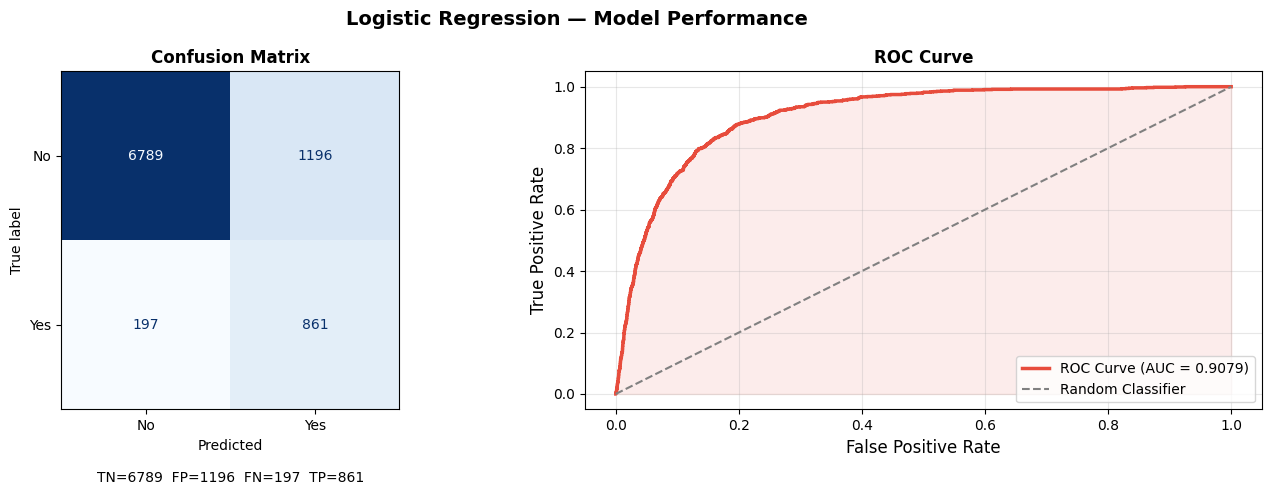

✅ Performance plots saved!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Logistic Regression — Model Performance', fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No', 'Yes'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')

# Add annotations
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(f'Predicted\n\nTN={tn}  FP={fp}  FN={fn}  TP={tp}', fontsize=10)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2.5,
             label=f'ROC Curve (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1.5,
             linestyle='--', label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Performance plots saved!")

🔝 Top 20 Most Important Features:


,Feature,Coefficient,Abs_Coef
3,duration,1.526409,1.526409
27,contact_unknown,-0.733499,0.733499
40,poutcome_success,0.451346,0.451346
32,month_jul,-0.402798,0.402798
24,housing_yes,-0.384133,0.384133
35,month_may,-0.355000,0.355000
28,month_aug,-0.328285,0.328285
36,month_nov,-0.289399,0.289399
4,campaign,-0.278326,0.278326
31,month_jan,-0.234466,0.234466


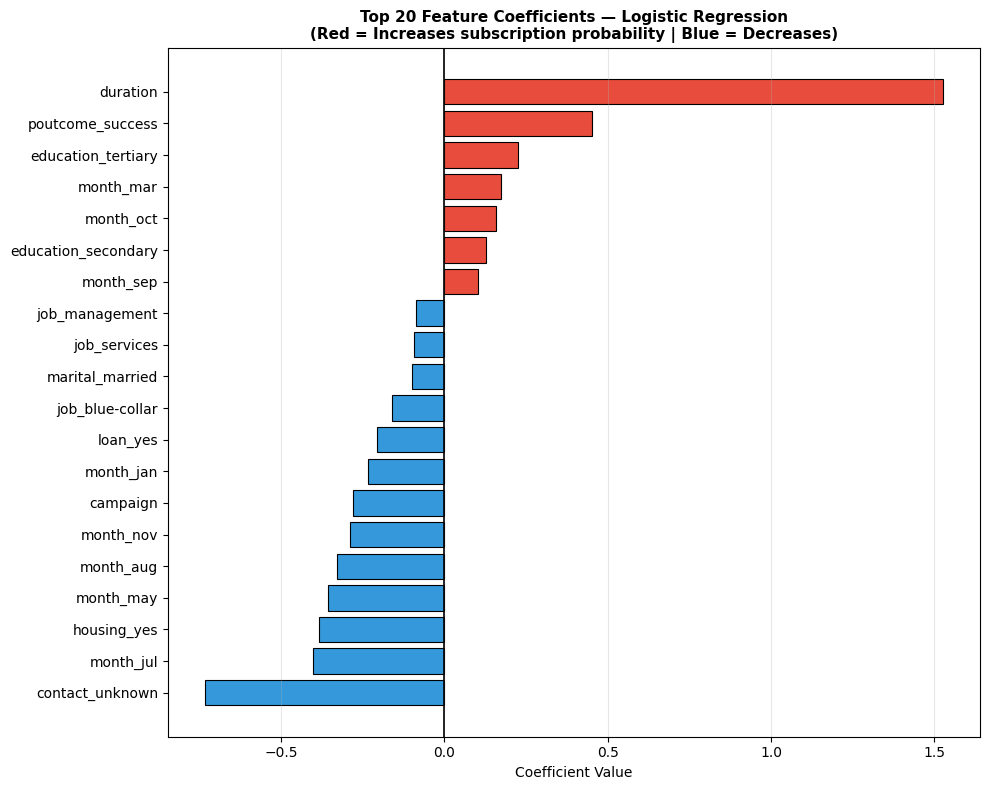

✅ Feature importance plot saved!


In [ ]:
# Get feature names and coefficients
feature_names = X.columns.tolist()
coefficients  = log_reg.coef_[0]

coef_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': coefficients,
    'Abs_Coef'   : np.abs(coefficients)
}).sort_values('Abs_Coef', ascending=False)

print("🔝 Top 20 Most Important Features:")
display(coef_df.head(20))

# Plot top 20
top20 = coef_df.head(20).sort_values('Coefficient')
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top20['Coefficient']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top20['Feature'], top20['Coefficient'],
               color=colors, edgecolor='black', linewidth=0.8)
ax.axvline(x=0, color='black', linewidth=1.2, linestyle='-')
ax.set_title('Top 20 Feature Coefficients — Logistic Regression\n'
             '(Red = Increases subscription probability | Blue = Decreases)',
             fontweight='bold', fontsize=11)
ax.set_xlabel('Coefficient Value')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('/content/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance plot saved!")

  5-FOLD STRATIFIED CROSS-VALIDATION

  Accuracy : 0.8446 ± 0.0028
  ROC-AUC  : 0.9097 ± 0.0052
  F1-Score : 0.5522 ± 0.0057


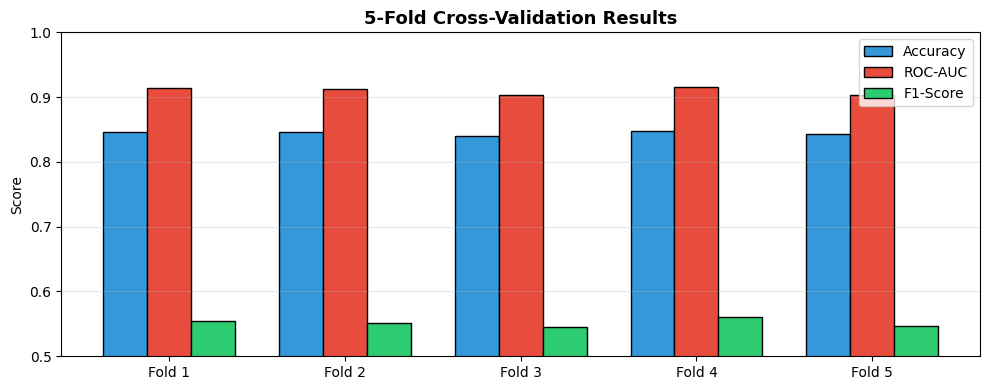

✅ Cross-validation plot saved!


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validate on full scaled data
from sklearn.preprocessing import StandardScaler
X_all_scaled = StandardScaler().fit_transform(X)

cv_accuracy = cross_val_score(log_reg, X_all_scaled, y, cv=cv,
                               scoring='accuracy', n_jobs=-1)
cv_auc      = cross_val_score(log_reg, X_all_scaled, y, cv=cv,
                               scoring='roc_auc', n_jobs=-1)
cv_f1       = cross_val_score(log_reg, X_all_scaled, y, cv=cv,
                               scoring='f1', n_jobs=-1)

print("=" * 50)
print("  5-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 50)
print(f"\n  Accuracy : {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}")
print(f"  ROC-AUC  : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"  F1-Score : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

# Plot CV results
fig, ax = plt.subplots(figsize=(10, 4))
folds = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5)
width = 0.25

ax.bar(x - width, cv_accuracy, width, label='Accuracy', color='#3498db', edgecolor='black')
ax.bar(x,         cv_auc,      width, label='ROC-AUC',  color='#e74c3c', edgecolor='black')
ax.bar(x + width, cv_f1,       width, label='F1-Score', color='#2ecc71', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.set_ylim(0.5, 1.0)
ax.set_title('5-Fold Cross-Validation Results', fontweight='bold', fontsize=13)
ax.set_ylabel('Score')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('/content/cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Cross-validation plot saved!")

🎯 Optimal Threshold: 0.67
   Best F1-Score    : 0.5844

📋 Classification Report at Threshold = 0.67:
              precision    recall  f1-score   support

          No       0.96      0.91      0.93      7985
         Yes       0.51      0.69      0.58      1058

    accuracy                           0.88      9043
   macro avg       0.73      0.80      0.76      9043
weighted avg       0.90      0.88      0.89      9043



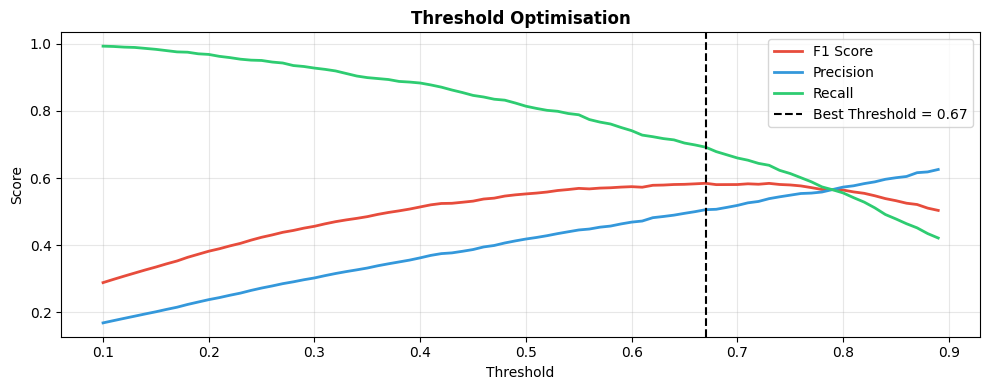

✅ Threshold plot saved!


In [ ]:
# Find optimal threshold using F1 score
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores, prec_scores, rec_scores = [], [], []

for thresh in thresholds:
    y_pred_t = (y_pred_proba >= thresh).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))
    prec_scores.append(precision_score(y_test, y_pred_t, zero_division=0))
    rec_scores.append(recall_score(y_test, y_pred_t, zero_division=0))

best_thresh = thresholds[np.argmax(f1_scores)]
best_f1     = max(f1_scores)

print(f"🎯 Optimal Threshold: {best_thresh:.2f}")
print(f"   Best F1-Score    : {best_f1:.4f}")

# Re-evaluate with optimal threshold
y_pred_opt = (y_pred_proba >= best_thresh).astype(int)
print(f"\n📋 Classification Report at Threshold = {best_thresh:.2f}:")
print(classification_report(y_test, y_pred_opt, target_names=['No', 'Yes']))

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_scores,   label='F1 Score',  color='#e74c3c', lw=2)
ax.plot(thresholds, prec_scores, label='Precision', color='#3498db', lw=2)
ax.plot(thresholds, rec_scores,  label='Recall',    color='#2ecc71', lw=2)
ax.axvline(x=best_thresh, color='black', linestyle='--', lw=1.5,
           label=f'Best Threshold = {best_thresh:.2f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Optimisation', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/threshold_optimisation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Threshold plot saved!")

In [ ]:
import shutil
import pickle

save_dir = '/content/drive/MyDrive/BankMarketingLR_Results'
os.makedirs(save_dir, exist_ok=True)

# Save model
with open('/content/logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(log_reg, f)

# Save scaler
with open('/content/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Copy files
files_to_save = [
    '/content/logistic_regression_model.pkl',
    '/content/scaler.pkl',
    '/content/eda_plots.png',
    '/content/model_performance.png',
    '/content/feature_importance.png',
    '/content/cross_validation.png',
    '/content/threshold_optimisation.png',
]

for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, save_dir)
        print(f"✅ Saved: {os.path.basename(f)}")

print(f"\n🎉 All results saved to: {save_dir}")

# Final Summary
print("\n" + "=" * 55)
print("  FINAL MODEL SUMMARY")
print("=" * 55)
print(f"  Model       : Logistic Regression (L2, C=1.0)")
print(f"  Train Size  : {X_train.shape[0]:,} samples")
print(f"  Test Size   : {X_test.shape[0]:,} samples")
print(f"  Features    : {X.shape[1]}")
print(f"  Test Acc    : {acc*100:.2f}%")
print(f"  ROC-AUC     : {auc:.4f}")
print(f"  CV Accuracy : {cv_accuracy.mean()*100:.2f}% ± {cv_accuracy.std()*100:.2f}%")
print(f"  CV AUC      : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"  Opt. Thresh : {best_thresh:.2f}  (F1={best_f1:.4f})")
print("=" * 55)

✅ Saved: logistic_regression_model.pkl
✅ Saved: scaler.pkl
✅ Saved: eda_plots.png
✅ Saved: model_performance.png
✅ Saved: feature_importance.png
✅ Saved: cross_validation.png
✅ Saved: threshold_optimisation.png

🎉 All results saved to: /content/drive/MyDrive/BankMarketingLR_Results

  FINAL MODEL SUMMARY
  Model       : Logistic Regression (L2, C=1.0)
  Train Size  : 36,168 samples
  Test Size   : 9,043 samples
  Features    : 42
  Test Acc    : 84.60%
  ROC-AUC     : 0.9079
  CV Accuracy : 84.46% ± 0.28%
  CV AUC      : 0.9097 ± 0.0052
  Opt. Thresh : 0.67  (F1=0.5844)
